In [4]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(f"현재 파이썬 실행 경로: {sys.executable}")
print(f"현재 작업 폴더: {os.getcwd()}")
print(f"판다스 버전: {pd.__version__}")

현재 파이썬 실행 경로: c:\projects\pregnancy_prediction_ML-DL프로젝트\.venv\Scripts\python.exe
현재 작업 폴더: c:\projects\pregnancy_prediction_ML-DL프로젝트
판다스 버전: 3.0.1


In [5]:


# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 데이터 로드 (경로 주의!)
train = pd.read_csv('data/train.csv')

# 요약 정보 출력
summary = pd.DataFrame({
    '타입': train.dtypes,
    '결측치수': train.isnull().sum(),
    '결측치비율(%)': (train.isnull().sum() / len(train) * 100).round(2),
    '고유값수': train.nunique(),
    '예시': train.iloc[0]
})

display(summary.sort_values(by='결측치비율(%)', ascending=False))






,타입,결측치수,결측치비율(%),고유값수,예시
난자 해동 경과일,float64,254915,99.44,2,NaN
PGS 시술 여부,float64,254422,99.25,1,NaN
PGD 시술 여부,float64,254172,99.15,1,NaN
착상 전 유전 검사 사용 여부,float64,253633,98.94,1,NaN
임신 시도 또는 마지막 임신 경과 연수,float64,246981,96.34,21,NaN
...,...,...,...,...,...
정자 기증자 나이,str,0,0.00,7,알 수 없음
난자 출처,str,0,0.00,3,본인 제공
정자 출처,str,0,0.00,4,배우자 제공
난자 기증자 나이,str,0,0.00,5,알 수 없음


In [7]:
# 전체 컬럼을 다 보여주도록 설정
pd.set_option('display.max_rows', None)

# 컬럼명과 데이터 타입을 세로로 출력
print(train.dtypes)

# 또는 컬럼 리스트만 깔끔하게 보고 싶을 때
# for col in train.columns:
#     print(col)

ID                           str
시술 시기 코드                     str
시술 당시 나이                     str
임신 시도 또는 마지막 임신 경과 연수    float64
시술 유형                        str
특정 시술 유형                     str
배란 자극 여부                   int64
배란 유도 유형                     str
단일 배아 이식 여부              float64
착상 전 유전 검사 사용 여부         float64
착상 전 유전 진단 사용 여부         float64
남성 주 불임 원인                 int64
남성 부 불임 원인                 int64
여성 주 불임 원인                 int64
여성 부 불임 원인                 int64
부부 주 불임 원인                 int64
부부 부 불임 원인                 int64
불명확 불임 원인                  int64
불임 원인 - 난관 질환              int64
불임 원인 - 남성 요인              int64
불임 원인 - 배란 장애              int64
불임 원인 - 여성 요인              int64
불임 원인 - 자궁경부 문제            int64
불임 원인 - 자궁내막증              int64
불임 원인 - 정자 농도              int64
불임 원인 - 정자 면역학적 요인         int64
불임 원인 - 정자 운동성             int64
불임 원인 - 정자 형태              int64
배아 생성 주요 이유                  str
총 시술 횟수                      str
클리닉 내 총 시술

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. 데이터 로드
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

# 2. 버릴 건 버린다 (Drop 전략)
# 90% 결측치 + 타겟 상관계수 없는 식별자 및 중복 컬럼 날리기
col_to_drop = [
    'ID', '난자 해동 경과일', 'PGS 시술 여부', 'PGD 시술 여부', '착상 전 유전 검사 사용 여부',
    'IVF 시술 횟수', 'DI 시술 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', 'IVF 출산 횟수', 'DI 출산 횟수' # 다중공선성 드랍
]
train.drop(columns=[col for col in col_to_drop if col in train.columns], inplace=True)
test.drop(columns=[col for col in col_to_drop if col in test.columns], inplace=True)

# 3. 데이터 타입 변환 (횟수를 int로)
def convert_count(val):
    if pd.isna(val): return 0
    return int(str(val).replace('회', '').replace(' 이상', '').strip())

count_cols = [col for col in train.columns if '횟수' in col]
for col in count_cols:
    train[col] = train[col].apply(convert_count)
    test[col] = test[col].apply(convert_count)

# 4. 파생 변수 생성 (Feature Engineering)
def create_features(df):
    df['이식_효율성'] = df['이식된 배아 수'] / (df['총 생성 배아 수'].fillna(0) + 1e-9)
    df['미세주입_성공률'] = df['미세주입에서 생성된 배아 수'] / (df['미세주입된 난자 수'].fillna(0) + 1e-9)
    df['과거_임신_성공률'] = df['총 임신 횟수'] / (df['총 시술 횟수'] + 1e-9)
    
    inf_cols = [col for col in df.columns if '불임 원인' in col]
    df[inf_cols] = df[inf_cols].fillna(0)
    df['불임_복잡도'] = df[inf_cols].sum(axis=1)
    return df

train = create_features(train)
test = create_features(test)

# 5. 인코딩 전략 적용
# 5-1. Ordinal Encoding (나이)
age_map = {'만18-34세': 0, '만35-37세': 1, '만38-39세': 2, '만40-42세': 3, '만43-44세': 4, '만45-50세': 5, '알 수 없음': -1}
train['시술 당시 나이'] = train['시술 당시 나이'].map(age_map)
test['시술 당시 나이'] = test['시술 당시 나이'].map(age_map)

# 5-2. Label Encoding (나머지 명목형 변수들)
obj_cols = train.select_dtypes(include=['object']).columns
for col in obj_cols:
    le = LabelEncoder()
    # train, test 데이터 셋을 합쳐서 한번에 핏(fit)해줘야 언노운(Unknown) 라벨 에러를 막을 수 있어
    le.fit(pd.concat([train[col].astype(str), test[col].astype(str)]))
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

# 6. 나머지 결측치는 트리 모델이 알아서 처리하거나 -1로 채우기
X_train = train.drop('임신 성공 여부', axis=1).fillna(-1)
y_train = train['임신 성공 여부']
X_test = test.fillna(-1)

print(" EDA 기반 전처리 및 인코딩 완료!")
print(f"현재 학습 피처 개수: {X_train.shape[1]}개")

C:\Users\PSJ\AppData\Local\Temp\ipykernel_14568\2853278306.py:49: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = train.select_dtypes(include=['object']).columns


 EDA 기반 전처리 및 인코딩 완료!
현재 학습 피처 개수: 61개


 [타겟과 양의 상관관계 TOP 10] (성공률 UP)
이식된 배아 수            0.157487
배아 이식 경과일           0.148590
총 생성 배아 수           0.146116
단일 배아 이식 여부         0.132635
혼합된 난자 수            0.116136
파트너 정자와 혼합된 난자 수    0.104902
미세주입에서 생성된 배아 수     0.090275
수집된 신선 난자 수         0.083023
미세주입 배아 이식 수        0.074351
미세주입된 난자 수          0.070117
Name: 임신 성공 여부, dtype: float64

 [타겟과 음의 상관관계 TOP 10] (성공률 DOWN)
난자 기증자 나이               -0.034398
배란 유도 유형                -0.040729
저장된 신선 난자 수             -0.047763
임신 시도 또는 마지막 임신 경과 연수   -0.051925
난자 출처                   -0.052500
클리닉 내 총 시술 횟수           -0.052820
총 시술 횟수                 -0.058923
시술 당시 나이                -0.148657
불임 원인 - 여성 요인                 NaN
난자 채취 경과일                     NaN
Name: 임신 성공 여부, dtype: float64


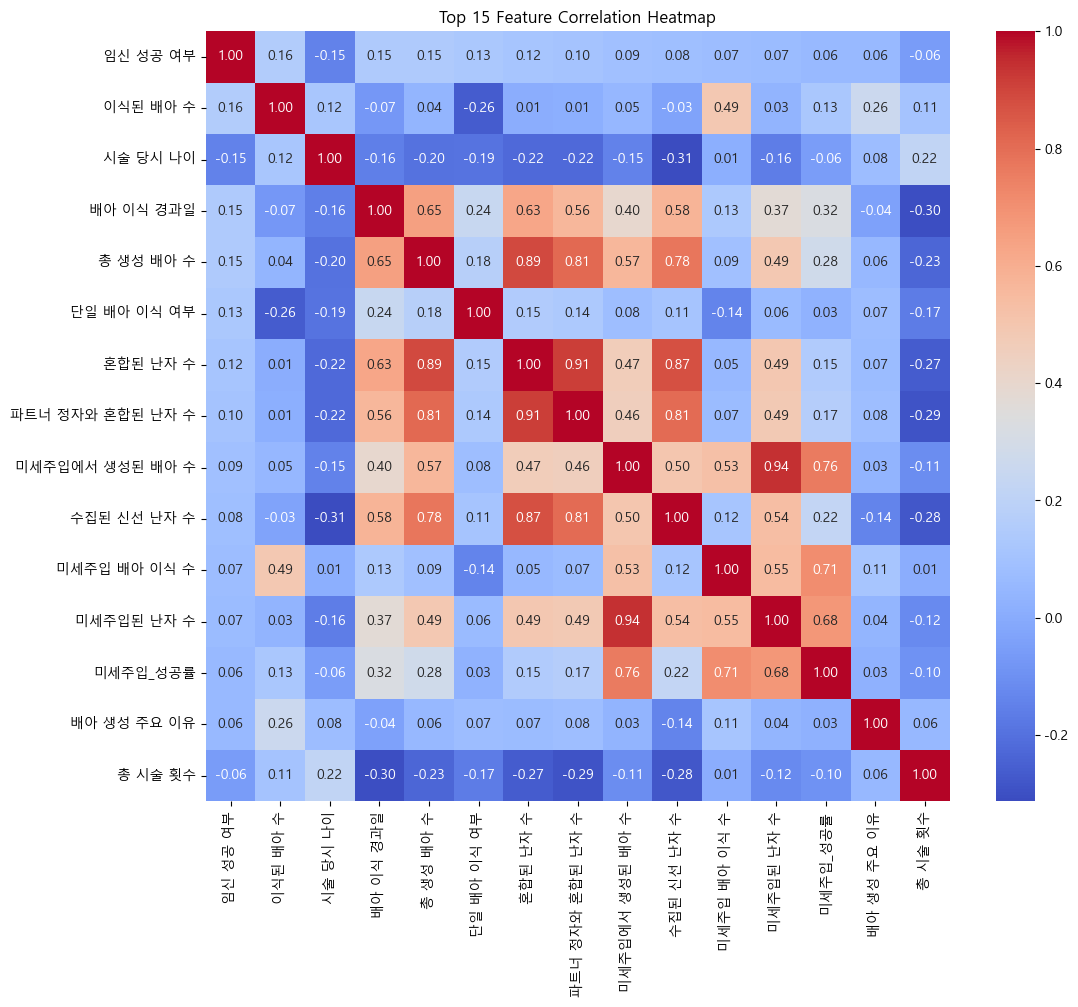

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 깨짐 방지 (윈도우 환경)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 타겟(임신 성공 여부)과의 상관계수 계산
corr = train.corr()
target_corr = corr['임신 성공 여부'].sort_values(ascending=False)

print(" [타겟과 양의 상관관계 TOP 10] (성공률 UP)")
print(target_corr.head(11).drop('임신 성공 여부'))
print("\n [타겟과 음의 상관관계 TOP 10] (성공률 DOWN)")
print(target_corr.tail(10))

# 다중공선성(Collinearity) 확인 (우리가 횟수 컬럼을 드랍한 이유)
if '총 시술 횟수' in corr.columns and 'IVF 시술 횟수' in corr.columns:
    print(f"\n 다중공선성 확인 (총 시술 횟수 vs IVF 시술 횟수): {corr.loc['총 시술 횟수', 'IVF 시술 횟수']:.4f}")

# 상위 15개 피처 히트맵 시각화
top_features = abs(target_corr).sort_values(ascending=False).head(15).index
plt.figure(figsize=(12, 10))
sns.heatmap(train[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 15 Feature Correlation Heatmap')
plt.show()

In [5]:
import optuna
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
from lightgbm import early_stopping, log_evaluation


In [8]:
# 1차 모델링 코드 (5-Fold Stratified K-Fold + LightGBM)


# # 1. 5-Fold 설정
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
cv_auc_scores = []

print(" LightGBM Stratified 5-Fold 학습 시작...\n")

# 2. 모델 학습 및 평가
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # 모델 정의 (5년차 엔지니어의 추천 초기 파라미터)
    model = LGBMClassifier(
        n_estimators=1000,       # 나무 개수는 넉넉하게
        learning_rate=0.03,      # 꼼꼼히 학습하도록 낮춤
        max_depth=8,             # 너무 깊어지지 않게 제한 (과적합 방지)
        num_leaves=63,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    )
    
    # Early Stopping 적용
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[

            early_stopping(stopping_rounds=50, verbose=False),
            log_evaluation(period=100)
        ]
    )
    
    # 검증셋 예측 및 평가
    val_probs = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_probs
    fold_auc = roc_auc_score(y_val, val_probs)
    cv_auc_scores.append(fold_auc)
    
    # 테스트셋 예측 (5번 예측해서 평균 냄)
    test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits
    
    print(f"▶ Fold {fold+1} AUC: {fold_auc:.4f}")

print("\n" + "="*30)
print(f" 최종 평균 CV AUC-ROC: {np.mean(cv_auc_scores):.4f}")
print("="*30)

# 3. 제출용 파일(submission.csv) 만들기
# 여기서 데이터 폴더 안에 있는 sample_submission을 불러옴
submission = pd.read_csv('data/sample_submission.csv')

# 예측한 확률값(임신 성공 확률)을 덮어씌움
# 제출 파일 형식이 'probability' 컬럼을 요구하는 경우
submission['probability'] = test_preds 

# 내 컴퓨터에 결과물 저장 (폴더 바깥에 저장할게)
submission.to_csv('my_first_submission.csv', index=False)
print("\n 제출 파일 생섯 (my_first_submission.csv)")

 LightGBM Stratified 5-Fold 학습 시작...

[100]	valid_0's auc: 0.736362	valid_0's binary_logloss: 0.4917
[200]	valid_0's auc: 0.736749	valid_0's binary_logloss: 0.48983
▶ Fold 1 AUC: 0.7369
[100]	valid_0's auc: 0.740003	valid_0's binary_logloss: 0.489582
[200]	valid_0's auc: 0.741288	valid_0's binary_logloss: 0.486945
▶ Fold 2 AUC: 0.7414
[100]	valid_0's auc: 0.738096	valid_0's binary_logloss: 0.490629
▶ Fold 3 AUC: 0.7387
[100]	valid_0's auc: 0.737408	valid_0's binary_logloss: 0.490539
[200]	valid_0's auc: 0.737588	valid_0's binary_logloss: 0.488673
▶ Fold 4 AUC: 0.7377
[100]	valid_0's auc: 0.738994	valid_0's binary_logloss: 0.490295
[200]	valid_0's auc: 0.739812	valid_0's binary_logloss: 0.488043
▶ Fold 5 AUC: 0.7399

 최종 평균 CV AUC-ROC: 0.7389

 제출 파일 생섯 (my_first_submission.csv)


In [ ]:
# # 2차 모델링 코드 (Optuna 하이퍼파라미터 튜닝 + LightGBM)


# # 1. Optuna 목적 함수 정의 (모델이 최적의 조합을 찾는 과정)
# def objective(trial):
#     # 모델이 테스트해 볼 파라미터 후보들 (여기가 핵심!)
#     params = {
#         'n_estimators': 1000,
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'max_depth': trial.suggest_int('max_depth', 4, 10),
#         'num_leaves': trial.suggest_int('num_leaves', 15, 127),
#         'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         # 불균형 데이터 극복을 위한 치트키 (실패 대비 성공의 가중치)
#         'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 3.5), 
#         'random_state': 42,
#         'n_jobs': -1,
#         'verbose': -1
#     }
    
#     skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     cv_auc = []
    
#     for train_idx, val_idx in skf.split(X_train, y_train):
#         X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
#         y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
#         model = LGBMClassifier(**params)
#         model.fit(
#             X_tr, y_tr,
#             eval_set=[(X_val, y_val)],
#             eval_metric='auc',
#             callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
#         )
        
#         val_probs = model.predict_proba(X_val)[:, 1]
#         cv_auc.append(roc_auc_score(y_val, val_probs))
        
#     return np.mean(cv_auc)

# # 2. Optuna 스터디 실행 (총 50번의 조합 테스트)
# study = optuna.create_study(direction='maximize')
# print(" Optuna 하이퍼파라미터 탐색 시작...")
# study.optimize(objective, n_trials=50)

# print("\n" + "="*30)
# print(f" 최적의 파라미터 조합: {study.best_params}")
# print(f" 최고 평균 CV AUC: {study.best_value:.4f}")
# print("="*30)

[I 2026-03-16 01:33:15,747] A new study created in memory with name: no-name-9b698e68-0228-42f8-aafb-1811ed096a42


 Optuna 하이퍼파라미터 탐색 시작...


[I 2026-03-16 01:33:24,886] Trial 0 finished with value: 0.7276189526519307 and parameters: {'learning_rate': 0.025191908733293068, 'max_depth': 4, 'num_leaves': 84, 'min_child_samples': 58, 'subsample': 0.7383228988151933, 'colsample_bytree': 0.6472588312718185, 'scale_pos_weight': 2.9338870280856604}. Best is trial 0 with value: 0.7276189526519307.
[I 2026-03-16 01:33:38,715] Trial 1 finished with value: 0.7369717390343998 and parameters: {'learning_rate': 0.027624897396347124, 'max_depth': 9, 'num_leaves': 75, 'min_child_samples': 20, 'subsample': 0.7454870837257546, 'colsample_bytree': 0.7008782204910322, 'scale_pos_weight': 2.089770153411104}. Best is trial 1 with value: 0.7369717390343998.
[I 2026-03-16 01:33:52,176] Trial 2 finished with value: 0.7363850469914427 and parameters: {'learning_rate': 0.024719815202799256, 'max_depth': 9, 'num_leaves': 95, 'min_child_samples': 21, 'subsample': 0.9062917436211835, 'colsample_bytree': 0.7350787968843808, 'scale_pos_weight': 2.870057795


 최적의 파라미터 조합: {'learning_rate': 0.012740978399136444, 'max_depth': 10, 'num_leaves': 33, 'min_child_samples': 55, 'subsample': 0.60083857340889, 'colsample_bytree': 0.7526010737254641, 'scale_pos_weight': 1.0924401714026877}
 최고 평균 CV AUC: 0.7396


In [9]:
# Optuna가 찾은 최종 레시피 적용
best_params = {
    'learning_rate': 0.012740978399136444,
    'max_depth': 10,
    'num_leaves': 33,
    'min_child_samples': 55,
    'subsample': 0.60083857340889,
    'colsample_bytree': 0.7526010737254641,
    'scale_pos_weight': 1.0924401714026877,
    # 아래는 모델 성능 안정성을 위해 추가하는 고정 파라미터야
    'n_estimators': 2000, 
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# 이 상태로 아까 알려준 '최종 모델 학습 및 제출' 셀을 실행하면 끝!

# 2. 최종 학습 및 5-Fold 앙상블
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_preds = np.zeros(len(X_test))

print(" Optuna 레시피로 최종 모델 학습 시작...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = LGBMClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[early_stopping(stopping_rounds=100), log_evaluation(period=200)]
    )
    # 5개의 모델이 각각 예측한 확률을 평균 내서 안정성을 높임
    test_preds += model.predict_proba(X_test)[:, 1] / 5
    print(f" Fold {fold+1} 완료")

# 3. 제출 파일 생성
import pandas as pd
submission = pd.read_csv('data/sample_submission.csv')
submission['probability'] = test_preds
submission.to_csv('optuna_적용세준_submission.csv', index=False)

print("\n 모든 작업 완료! 'optuna_final_submission.csv' 파일을 제출하세요")

 Optuna 레시피로 최종 모델 학습 시작...
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.735691	valid_0's binary_logloss: 0.494014
[400]	valid_0's auc: 0.737195	valid_0's binary_logloss: 0.490324
[600]	valid_0's auc: 0.737553	valid_0's binary_logloss: 0.49001
Early stopping, best iteration is:
[655]	valid_0's auc: 0.737579	valid_0's binary_logloss: 0.489993
 Fold 1 완료
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.739	valid_0's binary_logloss: 0.492251
[400]	valid_0's auc: 0.741433	valid_0's binary_logloss: 0.487792
[600]	valid_0's auc: 0.742242	valid_0's binary_logloss: 0.487182
[800]	valid_0's auc: 0.742482	valid_0's binary_logloss: 0.48702
Early stopping, best iteration is:
[891]	valid_0's auc: 0.742525	valid_0's binary_logloss: 0.486984
 Fold 2 완료
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.73788	valid_0's binary_logloss: 0.493015
[400]	valid_0's auc: 0.739412	valid_0's binary_log

In [10]:

# 1. 피처 다이어트: 상관계수 0.03 미만 노이즈 날리기
corr = train.corr()
target_corr = abs(corr['임신 성공 여부'])
weak_features = target_corr[target_corr < 0.03].index.tolist()

# 도메인 지식으로 만든 파생변수는 무조건 살리기
safe_cols = ['이식_효율성', '미세주입_성공률', '과거_임신_성공률', '불임_복잡도']
cols_to_drop = [col for col in weak_features if col not in safe_cols]

print(f" 날려버릴 노이즈 피처 {len(cols_to_drop)}개:\n{cols_to_drop}\n")

# 훈련셋, 테스트셋에서 드랍
X_train_diet = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test_diet = X_test.drop(columns=cols_to_drop, errors='ignore')

# 2. 얕은 나무 모델 (오버피팅 방어)
stump_params = {
    'n_estimators': 1500,     
    'learning_rate': 0.02,    
    'max_depth': 3,           # 깊이 3의 아주 단순한 나무
    'num_leaves': 7,          
    'colsample_bytree': 0.8,  
    'subsample': 0.8,         
    'scale_pos_weight': 1.2,  # 성공(1) 가중치 약간
    'random_state': 42,
    'n_jobs': -1
}

# 3. 5-Fold 학습 진행
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_preds_stump = np.zeros(len(X_test_diet))
cv_auc_scores = []

print(" [다이어트 + 얕은 나무] 학습 시작...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_diet, y_train)):
    X_tr, X_val = X_train_diet.iloc[train_idx], X_train_diet.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = LGBMClassifier(**stump_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[early_stopping(stopping_rounds=100, verbose=False)] 
    )
    
    val_probs = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, val_probs)
    cv_auc_scores.append(fold_auc)
    test_preds_stump += model.predict_proba(X_test_diet)[:, 1] / skf.n_splits
    
    print(f"▶ Fold {fold+1} AUC: {fold_auc:.4f}")

print("\n" + "="*30)
print(f" 다이어트 모델 최종 평균 CV AUC: {np.mean(cv_auc_scores):.4f}")
print("="*30)

# 최종 제출 파일 저장
submission = pd.read_csv('data/sample_submission.csv')
submission['probability'] = test_preds_stump
submission.to_csv('diet_stump_submission.csv', index=False)
print("\n 제출 파일 생성 완료! (diet_stump_submission.csv)")

 날려버릴 노이즈 피처 30개:
['시술 시기 코드', '특정 시술 유형', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 배란 장애', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '총 임신 횟수', '총 출산 횟수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '기증자 정자와 혼합된 난자 수', '정자 출처', '정자 기증자 나이', '기증 배아 사용 여부', '대리모 여부', '난자 혼합 경과일', '배아 해동 경과일']

 [다이어트 + 얕은 나무] 학습 시작...
▶ Fold 1 AUC: 0.7361
▶ Fold 2 AUC: 0.7400
▶ Fold 3 AUC: 0.7374
▶ Fold 4 AUC: 0.7363
▶ Fold 5 AUC: 0.7383

 다이어트 모델 최종 평균 CV AUC: 0.7376

 제출 파일 생성 완료! (diet_stump_submission.csv)
